# Part 2: Fine-Tuning Diffusion Models for Domain-Specific Image Generation

# Setup + Dataset loading + Preprocessing

In [1]:
# Install the Required Libraries
!pip install -q diffusers transformers accelerate datasets peft bitsandbytes torchvision pillow ftfy tensorboard open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 108.5 MB/s eta 0:00:00


In [2]:
# Import the Libraries
import os
import math
import time
import torch
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from datasets import load_dataset
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

In [3]:
# Check whether GPU is available
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [18]:
# ------------------------------
# Main project configuration
# ------------------------------

# dataset name
dataset_name = "lambdalabs/naruto-blip-captions"

# Base model
base_model_name = "runwayml/stable-diffusion-v1-5"

# Image size
image_size = 512

# Random seed for reproducibility
seed = 42

# Output folder for all results
output_dir = "/content/drive/MyDrive/DATA266/Labs/Lab2/Part2/outputs"

# Create the output folder if it does not exist
os.makedirs(output_dir, exist_ok=True)

# Fix random seeds so results are more reproducible
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print("Configuration is ready.")
print("Dataset:", dataset_name)
print("Base model:", base_model_name)
print("Image size:", image_size)
print("Output folder:", output_dir)

Configuration is ready.
Dataset: lambdalabs/naruto-blip-captions
Base model: runwayml/stable-diffusion-v1-5
Image size: 512
Output folder: /content/drive/MyDrive/DATA266/Labs/Lab2/Part2/outputs


In [5]:
# Load the dataset from Hugging Face
dataset = load_dataset(dataset_name)
dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json:   0%|          | 0.00/897 [00:00<?, ?B/s]

data/train-00000-of-00002-12944970063701(…):   0%|          | 0.00/344M [00:00<?, ?B/s]

data/train-00001-of-00002-cefa2f480689f1(…):   0%|          | 0.00/357M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1221 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 1221
    })
})

In [7]:
# Check how many samples are in the train split
print("\nNumber of training samples:")
print(len(dataset["train"]))

# Print the dataset column names
print("\nColumns in the train split:")
print(dataset["train"].column_names)


Number of training samples:
1221

Columns in the train split:
['image', 'text']


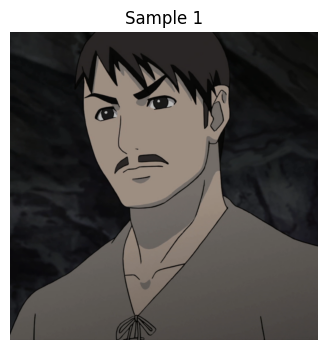

Caption: a man with dark hair and brown eyes
--------------------------------------------------------------------------------


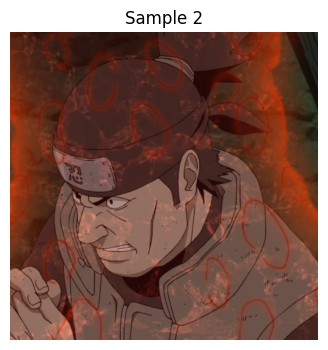

Caption: a man in a hoodie with a fire in the background
--------------------------------------------------------------------------------


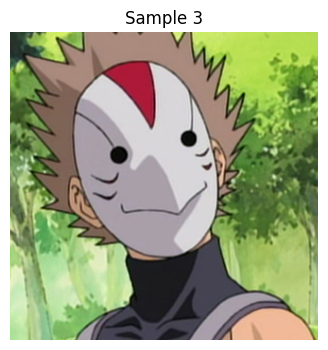

Caption: a man with a red hair and a black shirt
--------------------------------------------------------------------------------


In [8]:
# Show a few image-caption pairs from the dataset
for i in range(3):
    sample = dataset["train"][i]
    image = sample["image"]
    caption = sample["text"]
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Sample {i+1}")
    plt.show()
    print("Caption:", caption)
    print("-" * 80)

In [10]:
# Create a small table of captions so we can inspect how they are written
# for understanding caption style and quality
sample_caption_count = 10
sample_captions = [dataset["train"][i]["text"] for i in range(sample_caption_count)]
caption_df = pd.DataFrame({
    "sample_index": list(range(sample_caption_count)),
    "caption": sample_captions
})
caption_df

,sample_index,caption
0,0,a man with dark hair and brown eyes
1,1,a man in a hoodie with a fire in the background
2,2,a man with a red hair and a black shirt
3,3,a man in a blue shirt and headband
4,4,a dog in a blue shirt laying on the ground
5,5,a man in a blue and white outfit
6,6,a man with a white hair and a blue shirt
7,7,a dog with a banda around its neck
8,8,a person with blue hair and green eyes
9,9,a man in a suit and a panda bear


In [11]:
# Define image preprocessing transforms
image_transform = transforms.Compose([
    transforms.Resize(image_size, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

In [20]:
# Define a custom dataset class for image-caption pairs

class NarutoCaptionDataset(Dataset):
    def __init__(self, hf_dataset, image_transform=None):
        self.hf_dataset = hf_dataset
        self.image_transform = image_transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, index):
        sample = self.hf_dataset[index]

        image = sample["image"].convert("RGB")
        caption = sample["text"]

        if self.image_transform is not None:
            image = self.image_transform(image)

        return {
            "pixel_values": image,
            "caption": caption
        }

# Create the training dataset
train_dataset = NarutoCaptionDataset(
    hf_dataset=dataset["train"],
    image_transform=image_transform
)
print("Number of samples:", len(train_dataset))

Number of samples: 1221


In [21]:
# Check one processed sample
sample = train_dataset[0]
print("Keys in sample:", sample.keys())
print("Image tensor shape:", sample["pixel_values"].shape)
print("Caption:", sample["caption"])

Keys in sample: dict_keys(['pixel_values', 'caption'])
Image tensor shape: torch.Size([3, 512, 512])
Caption: a man with dark hair and brown eyes


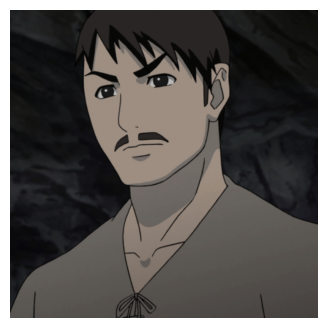

In [22]:
# Function to convert a normalized tensor back into a displayable image
def show_tensor_image(image_tensor):
    # Move tensor to CPU if needed
    image = image_tensor.detach().cpu()

    # Change shape from [C, H, W] to [H, W, C]
    image = image.permute(1, 2, 0).numpy()

    # Convert from [-1, 1] back to [0, 1]
    image = (image + 1.0) / 2.0

    # Clip values just in case
    image = np.clip(image, 0, 1)

    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

# Show one processed image
show_tensor_image(sample["pixel_values"])

In [16]:
# Define a fixed evaluation prompt set. 3 in-domain prompts and 3 out-of-domain prompts
evaluation_prompts = {
    "in_domain": [
        "a young ninja with spiky blond hair wearing an orange outfit, anime style",
        "a serious ninja with dark hair standing in a forest, anime illustration",
        "a female anime ninja with long hair and detailed clothing, dramatic lighting"
    ],
    "out_of_domain": [
        "a realistic astronaut walking on the moon under a dark sky",
        "a medieval castle on a snowy mountain at sunset",
        "a futuristic robot standing in a neon cyberpunk city"
    ]
}

print("In-domain prompts:")
for i, prompt in enumerate(evaluation_prompts["in_domain"], start=1):
    print(f"{i}. {prompt}")

print("\nOut-of-domain prompts:")
for i, prompt in enumerate(evaluation_prompts["out_of_domain"], start=1):
    print(f"{i}. {prompt}")

In-domain prompts:
1. a young ninja with spiky blond hair wearing an orange outfit, anime style
2. a serious ninja with dark hair standing in a forest, anime illustration
3. a female anime ninja with long hair and detailed clothing, dramatic lighting

Out-of-domain prompts:
1. a realistic astronaut walking on the moon under a dark sky
2. a medieval castle on a snowy mountain at sunset
3. a futuristic robot standing in a neon cyberpunk city


In [19]:
# Save the evaluation prompts to a text file
prompt_file_path = os.path.join(output_dir, "evaluation_prompts.txt")
with open(prompt_file_path, "w", encoding="utf-8") as file:
    file.write("In-domain prompts:\n")
    for prompt in evaluation_prompts["in_domain"]:
        file.write(f"- {prompt}\n")

    file.write("\nOut-of-domain prompts:\n")
    for prompt in evaluation_prompts["out_of_domain"]:
        file.write(f"- {prompt}\n")
print(prompt_file_path)

/content/drive/MyDrive/DATA266/Labs/Lab2/Part2/outputs/evaluation_prompts.txt


# Base Model Generation

In [23]:
# Import the Stable Diffusion pipeline from Diffusers
from diffusers import StableDiffusionPipeline

# We will load the base model in float16 mode
torch_dtype = torch.float16 if device == "cuda" else torch.float32

# Load the base Stable Diffusion 1.5 pipeline
base_pipeline = StableDiffusionPipeline.from_pretrained(
    base_model_name,
    torch_dtype=torch_dtype
)

# Move the pipeline to GPU if available
base_pipeline = base_pipeline.to(device)
print("Base Stable Diffusion 1.5 pipeline loaded successfully.")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Base Stable Diffusion 1.5 pipeline loaded successfully.


In [24]:
# Define a function to generate images from a prompt
def generate_images_from_prompt(
    pipeline,
    prompt,
    num_images=2,
    guidance_scale=7.5,
    num_inference_steps=30,
    seed=42
):
    generated_images = []
    for image_index in range(num_images):
        generator = torch.Generator(device=device).manual_seed(seed + image_index)
        result = pipeline(
            prompt=prompt,
            guidance_scale=guidance_scale,
            num_inference_steps=num_inference_steps,
            generator=generator
        )
        image = result.images[0]
        generated_images.append(image)
    return generated_images

In [25]:
# Create a folder to save base model outputs
base_output_dir = os.path.join(output_dir, "base_model_outputs")
os.makedirs(base_output_dir, exist_ok=True)

# Combine all prompts into one list
all_prompts = evaluation_prompts["in_domain"] + evaluation_prompts["out_of_domain"]

# Store generated images in a dictionary for later use
base_generated_images = {}

# Generate 2 images per prompt
for prompt_index, prompt in enumerate(all_prompts):
    print(f"Generating images for prompt {prompt_index + 1}/{len(all_prompts)}")
    print("Prompt:", prompt)

    images = generate_images_from_prompt(
        pipeline=base_pipeline,
        prompt=prompt,
        num_images=2,
        guidance_scale=7.5,
        num_inference_steps=30,
        seed=seed + prompt_index * 10
    )

    base_generated_images[prompt] = images

    # Save each generated image
    for image_number, image in enumerate(images, start=1):
        image_filename = f"prompt_{prompt_index+1}_sample_{image_number}.png"
        image_path = os.path.join(base_output_dir, image_filename)
        image.save(image_path)

print("Base model image generation complete.")

Generating images for prompt 1/6
Prompt: a young ninja with spiky blond hair wearing an orange outfit, anime style


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Generating images for prompt 2/6
Prompt: a serious ninja with dark hair standing in a forest, anime illustration


  0%|          | 0/30 [00:00<?, ?it/s]

...

  0%|          | 0/30 [00:00<?, ?it/s]

Generating images for prompt 6/6
Prompt: a futuristic robot standing in a neon cyberpunk city


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Base model image generation complete.


In [26]:
# Display the base model results
for prompt_index, prompt in enumerate(all_prompts):
    print("=" * 100)
    print(f"Prompt {prompt_index + 1}: {prompt}")
    images = base_generated_images[prompt]
    plt.figure(figsize=(10, 5))
    for i, image in enumerate(images):
        plt.subplot(1, 2, i + 1)
        plt.imshow(image)
        plt.axis("off")
        plt.title(f"Base Output {i + 1}")
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

# Fine-tuning with LoRA

In [45]:
# Import the individual model components we need for custom diffusion training

from diffusers import AutoencoderKL
from diffusers import UNet2DConditionModel
from diffusers import DDPMScheduler
from transformers import CLIPTokenizer, CLIPTextModel

# PEFT imports for LoRA
from peft import PeftModel
from peft import LoraConfig, get_peft_model

In [30]:
# Load each component from the Stable Diffusion 1.5 model checkpoint
tokenizer = CLIPTokenizer.from_pretrained(
    base_model_name,
    subfolder="tokenizer"
)

text_encoder = CLIPTextModel.from_pretrained(
    base_model_name,
    subfolder="text_encoder"
)

vae = AutoencoderKL.from_pretrained(
    base_model_name,
    subfolder="vae"
)

unet = UNet2DConditionModel.from_pretrained(
    base_model_name,
    subfolder="unet"
)

noise_scheduler = DDPMScheduler.from_pretrained(
    base_model_name,
    subfolder="scheduler"
)

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: runwayml/stable-diffusion-v1-5
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [31]:
# Move models to the selected device
text_encoder = text_encoder.to(device)
vae = vae.to(device)
unet = unet.to(device)

In [32]:
# Freeze all original model parameters
vae.requires_grad_(False)
text_encoder.requires_grad_(False)
unet.requires_grad_(False)

UNet2DConditionModel(
  (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=320, out_features=1280, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=1280, out_features=1280, bias=True)
  )
  (down_blocks): ModuleList(
    (0): CrossAttnDownBlock2D(
      (attentions): ModuleList(
        (0-1): 2 x Transformer2DModel(
          (norm): GroupNorm(32, 320, eps=1e-06, affine=True)
          (proj_in): Conv2d(320, 320, kernel_size=(1, 1), stride=(1, 1))
          (transformer_blocks): ModuleList(
            (0): BasicTransformerBlock(
              (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
              (attn1): Attention(
                (to_q): Linear(in_features=320, out_features=320, bias=False)
                (to_k): Linear(in_features=320, out_features=320, bias=False)
                (to_v): Linear(in_features=320, out_fe

In [33]:
# Define a LoRA configuration
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    bias="none",
    target_modules=["to_q", "to_k", "to_v", "to_out.0"]
)

# Add LoRA adapters to the UNet
unet = get_peft_model(unet, lora_config)

In [34]:
# Check Which Parameters Are Trainable
unet.print_trainable_parameters()

trainable params: 1,594,368 || all params: 861,115,332 || trainable%: 0.1852


In [35]:
# Define a function to tokenize captions
def tokenize_caption(caption_text):
    tokenized_output = tokenizer(
        caption_text,
        padding="max_length",
        truncation=True,
        max_length=tokenizer.model_max_length,
        return_tensors="pt"
    )

    return tokenized_output.input_ids[0]

In [36]:
# Create a new dataset class that returns both image tensors and tokenized captions

class NarutoDiffusionDataset(Dataset):
    def __init__(self, hf_dataset, image_transform, tokenizer):
        self.hf_dataset = hf_dataset
        self.image_transform = image_transform
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, index):
        sample = self.hf_dataset[index]

        image = sample["image"].convert("RGB")
        caption = sample["text"]

        # Apply image preprocessing
        pixel_values = self.image_transform(image)

        # Tokenize the caption
        input_ids = self.tokenizer(
            caption,
            padding="max_length",
            truncation=True,
            max_length=self.tokenizer.model_max_length,
            return_tensors="pt"
        ).input_ids[0]

        return {
            "pixel_values": pixel_values,
            "input_ids": input_ids,
            "caption": caption
        }

In [38]:
# Create the training dataset and dataloader for diffusion training

train_dataset = NarutoDiffusionDataset(
    hf_dataset=dataset["train"],
    image_transform=image_transform,
    tokenizer=tokenizer
)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True
)

print("Number of training batches:", len(train_dataloader))

Number of training batches: 1221


In [39]:
# Create the optimizer for LoRA training
learning_rate = 1e-4
optimizer = torch.optim.AdamW(
    unet.parameters(),
    lr=learning_rate
)

In [40]:
# Training settings for the custom LoRA loop
num_epochs = 1
max_train_steps = 300
lora_loss_history = []

In [41]:
# Set the models to the correct mode before training
unet.train()

# VAE and text encoder stay frozen, so eval mode is fine
vae.eval()
text_encoder.eval()

CLIPTextModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 768)
      (position_embedding): Embedding(77, 768)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e

In [42]:
# LoRA training loop
global_step = 0
start_time = time.time()

for epoch in range(num_epochs):
    print(f"\nStarting epoch {epoch + 1}/{num_epochs}")

    for batch_index, batch in enumerate(train_dataloader):
        if global_step >= max_train_steps:
            break

        # Move image tensors and input IDs to the selected device
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)

        # Convert images into latent space
        with torch.no_grad():
            latents = vae.encode(pixel_values).latent_dist.sample()
            latents = latents * vae.config.scaling_factor

        # Sample random noise
        noise = torch.randn_like(latents)


        # Sample a random timestep
        batch_size = latents.shape[0]
        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (batch_size,),
            device=device
        ).long()

        # Add noise to the latent
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        # Encode the text caption
        with torch.no_grad():
            encoder_hidden_states = text_encoder(input_ids)[0]

        # Predict the noise using the UNet
        noise_prediction = unet(
            noisy_latents,
            timesteps,
            encoder_hidden_states
        ).sample

        # Compute the loss
        loss = torch.nn.functional.mse_loss(noise_prediction, noise)

        # Backpropagation and optimizer step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Save loss for later plotting
        lora_loss_history.append(loss.item())

        global_step += 1

        # Print progress sometimes
        if global_step % 20 == 0:
            print(f"Step {global_step}/{max_train_steps} - Loss: {loss.item():.4f}")

    if global_step >= max_train_steps:
        break

end_time = time.time()
lora_training_time_seconds = end_time - start_time

print("\nLoRA training complete.")
print("Total training steps:", global_step)
print("Approximate training time (seconds):", round(lora_training_time_seconds, 2))


Starting epoch 1/1
Step 20/300 - Loss: 0.1185
Step 40/300 - Loss: 0.1127
Step 60/300 - Loss: 0.4420
Step 80/300 - Loss: 0.0291
Step 100/300 - Loss: 0.0062
Step 120/300 - Loss: 0.0290
Step 140/300 - Loss: 0.0421
Step 160/300 - Loss: 0.0250
Step 180/300 - Loss: 0.0498
Step 200/300 - Loss: 0.0496
Step 220/300 - Loss: 0.0906
Step 240/300 - Loss: 0.2284
Step 260/300 - Loss: 0.4017
Step 280/300 - Loss: 0.2655
Step 300/300 - Loss: 0.1392

LoRA training complete.
Total training steps: 300
Approximate training time (seconds): 37.83


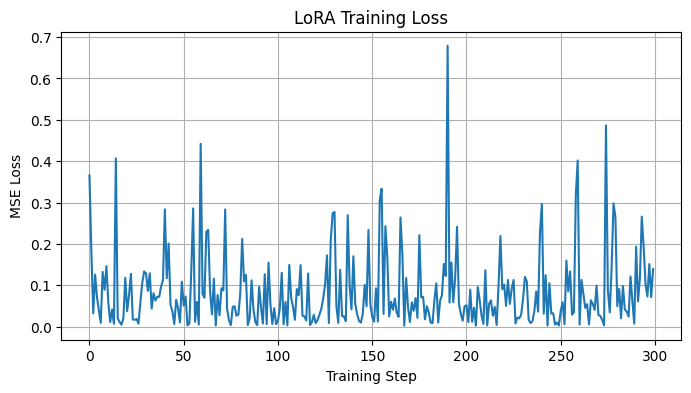

In [43]:
# Plot the LoRA training loss curve
plt.figure(figsize=(8, 4))
plt.plot(lora_loss_history)
plt.title("LoRA Training Loss")
plt.xlabel("Training Step")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

In [44]:
# Save the trained LoRA adapter weights
custom_lora_save_dir = os.path.join(output_dir, "lora_adapter_weights")
os.makedirs(custom_lora_save_dir, exist_ok=True)
unet.save_pretrained(custom_lora_save_dir)
print(custom_lora_save_dir)

/content/drive/MyDrive/DATA266/Labs/Lab2/Part2/outputs/lora_adapter_weights


In [49]:
# Load a fresh base UNet
lora_inference_unet = UNet2DConditionModel.from_pretrained(
    base_model_name,
    subfolder="unet"
).to(device)

# Load the saved LoRA adapter into the base UNet
lora_inference_unet = PeftModel.from_pretrained(
    lora_inference_unet,
    custom_lora_save_dir
)
lora_inference_unet = lora_inference_unet.to(device=device, dtype=torch_dtype)

In [50]:
# Load a fresh Stable Diffusion pipeline
lora_pipeline = StableDiffusionPipeline.from_pretrained(
    base_model_name,
    torch_dtype=torch_dtype
).to(device)

# Replace the pipeline UNet with the LoRA-adapted UNet
lora_pipeline.unet = lora_inference_unet

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [51]:
# Generate Images with the Custom LoRA Model
# Create a folder to save custom LoRA-generated outputs
lora_generated_output_dir = os.path.join(output_dir, "lora_generated_outputs")
os.makedirs(lora_generated_output_dir, exist_ok=True)

# Store generated images in a dictionary
lora_generated_images = {}

# Generate 2 images per prompt
for prompt_index, prompt in enumerate(all_prompts):
    print(f"Generating custom LoRA images for prompt {prompt_index + 1}/{len(all_prompts)}")
    print("Prompt:", prompt)

    images = generate_images_from_prompt(
        pipeline=lora_pipeline,
        prompt=prompt,
        num_images=2,
        guidance_scale=7.5,
        num_inference_steps=30,
        seed=seed + prompt_index * 10
    )

    lora_generated_images[prompt] = images

    for image_number, image in enumerate(images, start=1):
        image_filename = f"prompt_{prompt_index+1}_sample_{image_number}.png"
        image_path = os.path.join(lora_generated_output_dir, image_filename)
        image.save(image_path)

Generating custom LoRA images for prompt 1/6
Prompt: a young ninja with spiky blond hair wearing an orange outfit, anime style


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Generating custom LoRA images for prompt 2/6
Prompt: a serious ninja with dark hair standing in a forest, anime illustration


  0%|          | 0/30 [00:00<?, ?it/s]

...

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Generating custom LoRA images for prompt 6/6
Prompt: a futuristic robot standing in a neon cyberpunk city


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

In [52]:
# LoRA Outputs
for prompt_index, prompt in enumerate(all_prompts):
    print("=" * 100)
    print(f"Prompt {prompt_index + 1}: {prompt}")
    base_images = base_generated_images[prompt]
    lora_images = lora_generated_images[prompt]
    plt.figure(figsize=(14, 8))
    for i, image in enumerate(lora_images):
        plt.subplot(2, 2, i + 3)
        plt.imshow(image)
        plt.axis("off")
        plt.title(f"Custom LoRA Output {i + 1}")
    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

# Full fine-tuning